## Phase stability

In this notebook, we look at the stability of different crystal phases of pure lead at different temperatures and pressures. At fixed $T$ and $P$, the stable phase is the one with the lowest Gibbs free energy, $G(T, P) = \min_V \left[ F(V, T) + PV \right]$. A phase transition occurs where the free energies of two phases cross. Following those crossings across a grid of temperatures and pressures traces out the phase boundaries of the unary phase diagram.

We compute $F(V, T)$ in the quasiharmonic approximation: for each phase, the static lattice energy plus the harmonic vibrational free energy from phonons, evaluated over a grid of volumes. Minimising $F + PV$ over a polynomial fit in volume gives $G$, and the volume grid is re-centred and narrowed around the minimum until $G$ stops changing. Running this for FCC, HCP and BCC lead near the expected FCC → HCP and HCP → BCC transition pressures, we interpolate where $\Delta G$ changes sign to locate the transition pressure at each temperature.

The quasiharmonic approximation captures thermal expansion, through the volume dependence of the phonon frequencies, and the phonon free energy is quantum mechanical, so it includes zero-point motion. What it leaves out is anharmonicity at fixed volume: atoms are treated as independent harmonic oscillators, with no phonon–phonon scattering and no temperature dependence of the vibrational frequencies themselves.

Finally, everything is only as good as the interatomic potential: it puts the transitions near 57 and 84 GPa, whereas experiment finds lead's transitions at roughly 13 and 109 GPa. This notebook demonstrates the workflow in reasonable amount of compute time, not a quantitative phase diagram of lead.

In [1]:
import importlib.metadata
import pathlib
import shutil
from concurrent import futures

import bagofholding as boh
import numpy as np
import pyiron_workflow as pwf
from ase import build
from matplotlib import pyplot as plt
from pyiron_workflow_atomistics import engine as engine_mod

import pmd03

We already know a few rough properties about this material and these phases, so let's write some geometry helpers to get us some decent first-guesses for different structures at different pressures

In [2]:
COVERA = np.sqrt(8.0 / 3.0)
FCC_V_57GPA = 20.7
HCP_V_57GPA = 20.6
HCP_V_84GPA = 19.1
BCC_V_84GPA = 18.9
SPECIES = "Pb"

def fcc_at(volume_per_atom, species=SPECIES):
    return build.bulk(species, "fcc", a=(4.0 * volume_per_atom) ** (1 / 3), cubic=True)


def bcc_at(volume_per_atom, species=SPECIES):
    return build.bulk(species, "bcc", a=(2.0 * volume_per_atom) ** (1 / 3), cubic=True)


def hcp_at(volume_per_atom, covera=COVERA, species=SPECIES):
    # Hexagonal, not orthorhombic: same phonons to 0.03 meV/atom in 200 atoms
    # instead of 240, and it keeps the cell's hexagonal point group so phonopy
    # does not warn. `apply_strains`' c_over_a mode scales the cell rows by
    # (g, g, f), which is exactly the c/a strain on a hexagonal cell.
    a = (4.0 * volume_per_atom / (np.sqrt(3.0) * covera)) ** (1 / 3)
    return build.bulk(species, "hcp", a=a, covera=covera)

Then, let's jump in and start building our workflow. As we increase pressure, we expect from [the literature](https://arxiv.org/pdf/2605.16018) that  [the EAM potential we're using](https://iopscience.iop.org/article/10.1088/0953-8984/28/50/505201/meta) will show phases proceeding from FCC to HCP to BCC with increasing pressure. Let's use our library to build low- and high-pressure structure pairs to examine differences in the free energy around the observed transition pressures:

In [3]:
wf = pwf.Workflow("sweep_lo")

wf.fcc_lo = pwf.node(pmd03.gibbs_over_pressures)

wf.create_input_for(wf.fcc_lo.inputs.structure, label="fcc_structure_lo")
wf.create_input_for(wf.fcc_lo.inputs.engine)
wf.create_input_for(wf.fcc_lo.inputs.pressures, label="pressures_lo")
wf.create_input_for(wf.fcc_lo.inputs.temperatures)
wf.create_input_for(wf.fcc_lo.inputs.shape_objective)
wf.create_input_for(wf.fcc_lo.inputs.gibbs_tolerance)
wf.create_input_for(wf.fcc_lo.inputs.num_points)
wf.create_input_for(wf.fcc_lo.inputs.max_iterations)
wf.create_input_for(wf.fcc_lo.inputs.working_directory)
wf.create_input_for(wf.fcc_lo.inputs.tag, label="fcc_tag_lo")

wf.hcp_lo = pwf.node(
    pmd03.gibbs_over_pressures,
    engine=wf.inputs.engine,
    pressures=wf.inputs.pressures_lo,
    temperatures=wf.inputs.temperatures,
    shape_objective=wf.inputs.shape_objective,
    gibbs_tolerance=wf.inputs.gibbs_tolerance,
    num_points=wf.inputs.num_points,
    max_iterations=wf.inputs.max_iterations,
    working_directory=wf.inputs.working_directory,
)
wf.create_input_for(wf.hcp_lo.inputs.structure, label="hcp_structure_lo")
wf.create_input_for(wf.hcp_lo.inputs.tag, label="hcp_tag_lo")

wf.hcp_hi = pwf.node(
    pmd03.gibbs_over_pressures,
    engine=wf.inputs.engine,
    temperatures=wf.inputs.temperatures,
    shape_objective=wf.inputs.shape_objective,
    gibbs_tolerance=wf.inputs.gibbs_tolerance,
    num_points=wf.inputs.num_points,
    max_iterations=wf.inputs.max_iterations,
    working_directory=wf.inputs.working_directory,
)
wf.create_input_for(wf.hcp_hi.inputs.pressures, label="pressures_hi")
wf.create_input_for(wf.hcp_hi.inputs.structure, label="hcp_structure_hi")
wf.create_input_for(wf.hcp_hi.inputs.tag, label="hcp_tag_hi")

wf.bcc_hi = pwf.node(
    pmd03.gibbs_over_pressures,
    engine=wf.inputs.engine,
    pressures=wf.inputs.pressures_hi,
    temperatures=wf.inputs.temperatures,
    shape_objective=wf.inputs.shape_objective,
    gibbs_tolerance=wf.inputs.gibbs_tolerance,
    num_points=wf.inputs.num_points,
    max_iterations=wf.inputs.max_iterations,
    working_directory=wf.inputs.working_directory,
)
wf.create_input_for(wf.bcc_hi.inputs.structure, label="bcc_structure_hi")
wf.create_input_for(wf.bcc_hi.inputs.tag, label="bcc_tag_hi")

wf.create_output_from(wf.fcc_lo, label="fcc_sweep_lo")
wf.create_output_from(wf.hcp_lo, label="hcp_sweep_lo")
wf.create_output_from(wf.hcp_hi, label="hcp_sweep_hi")
wf.create_output_from(wf.bcc_hi, label="bcc_sweep_hi")

[AddOutput(port=OutputPort(label='bcc_sweep_hi', owner=<pyiron_workflow.workflow_node.Workflow object at 0x11dc457f0>, type_hint=<class 'pmd03.gibbs_nodes.GibbsSweep'>, type_metadata=None)),
 AddEdge(edge=EdgeTuple(source=SourceHandle(node='bcc_hi', port='gibbs_sweep'), target=OutputTarget(node=None, port='bcc_sweep_hi')))]

Seen graphically, we run our re-usable gibbs routine at different crystal structures and pressures

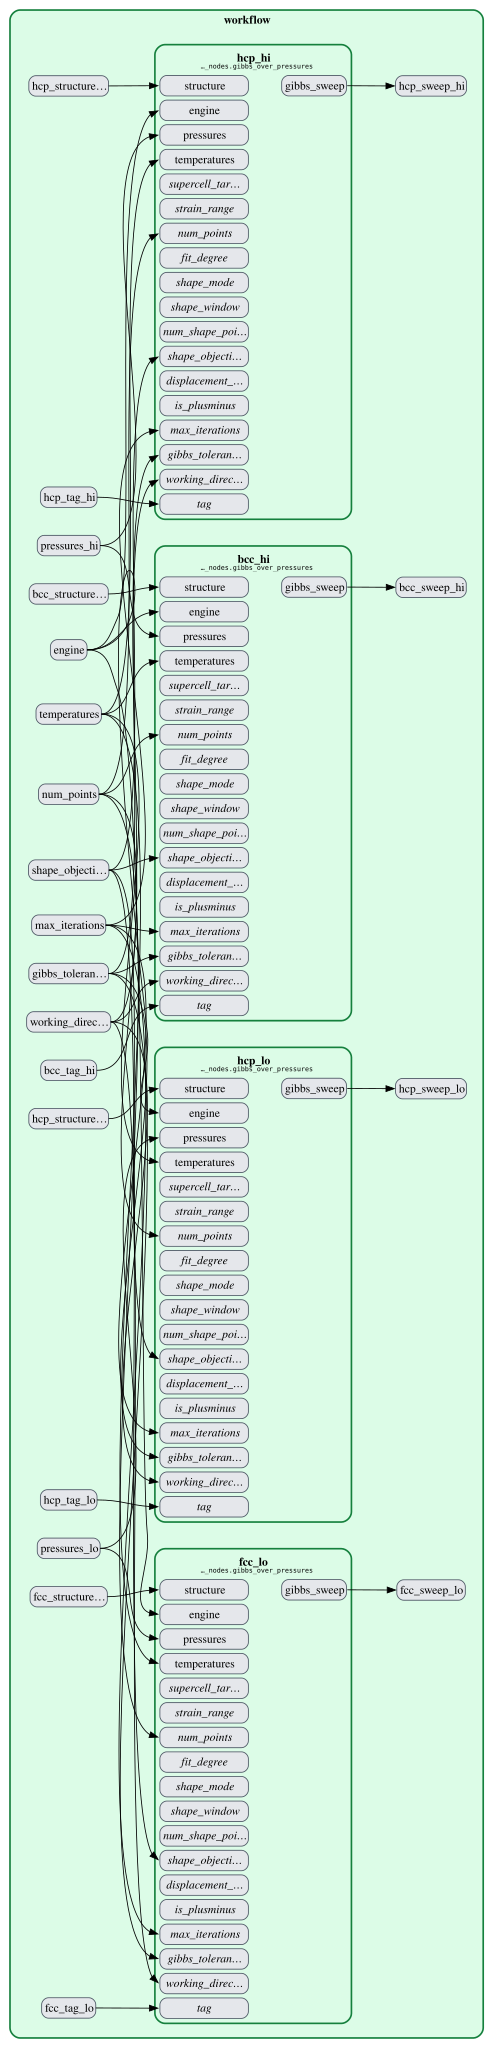

In [4]:
wf.draw(depth=0)

We can also visualize the internals of the re-used component:

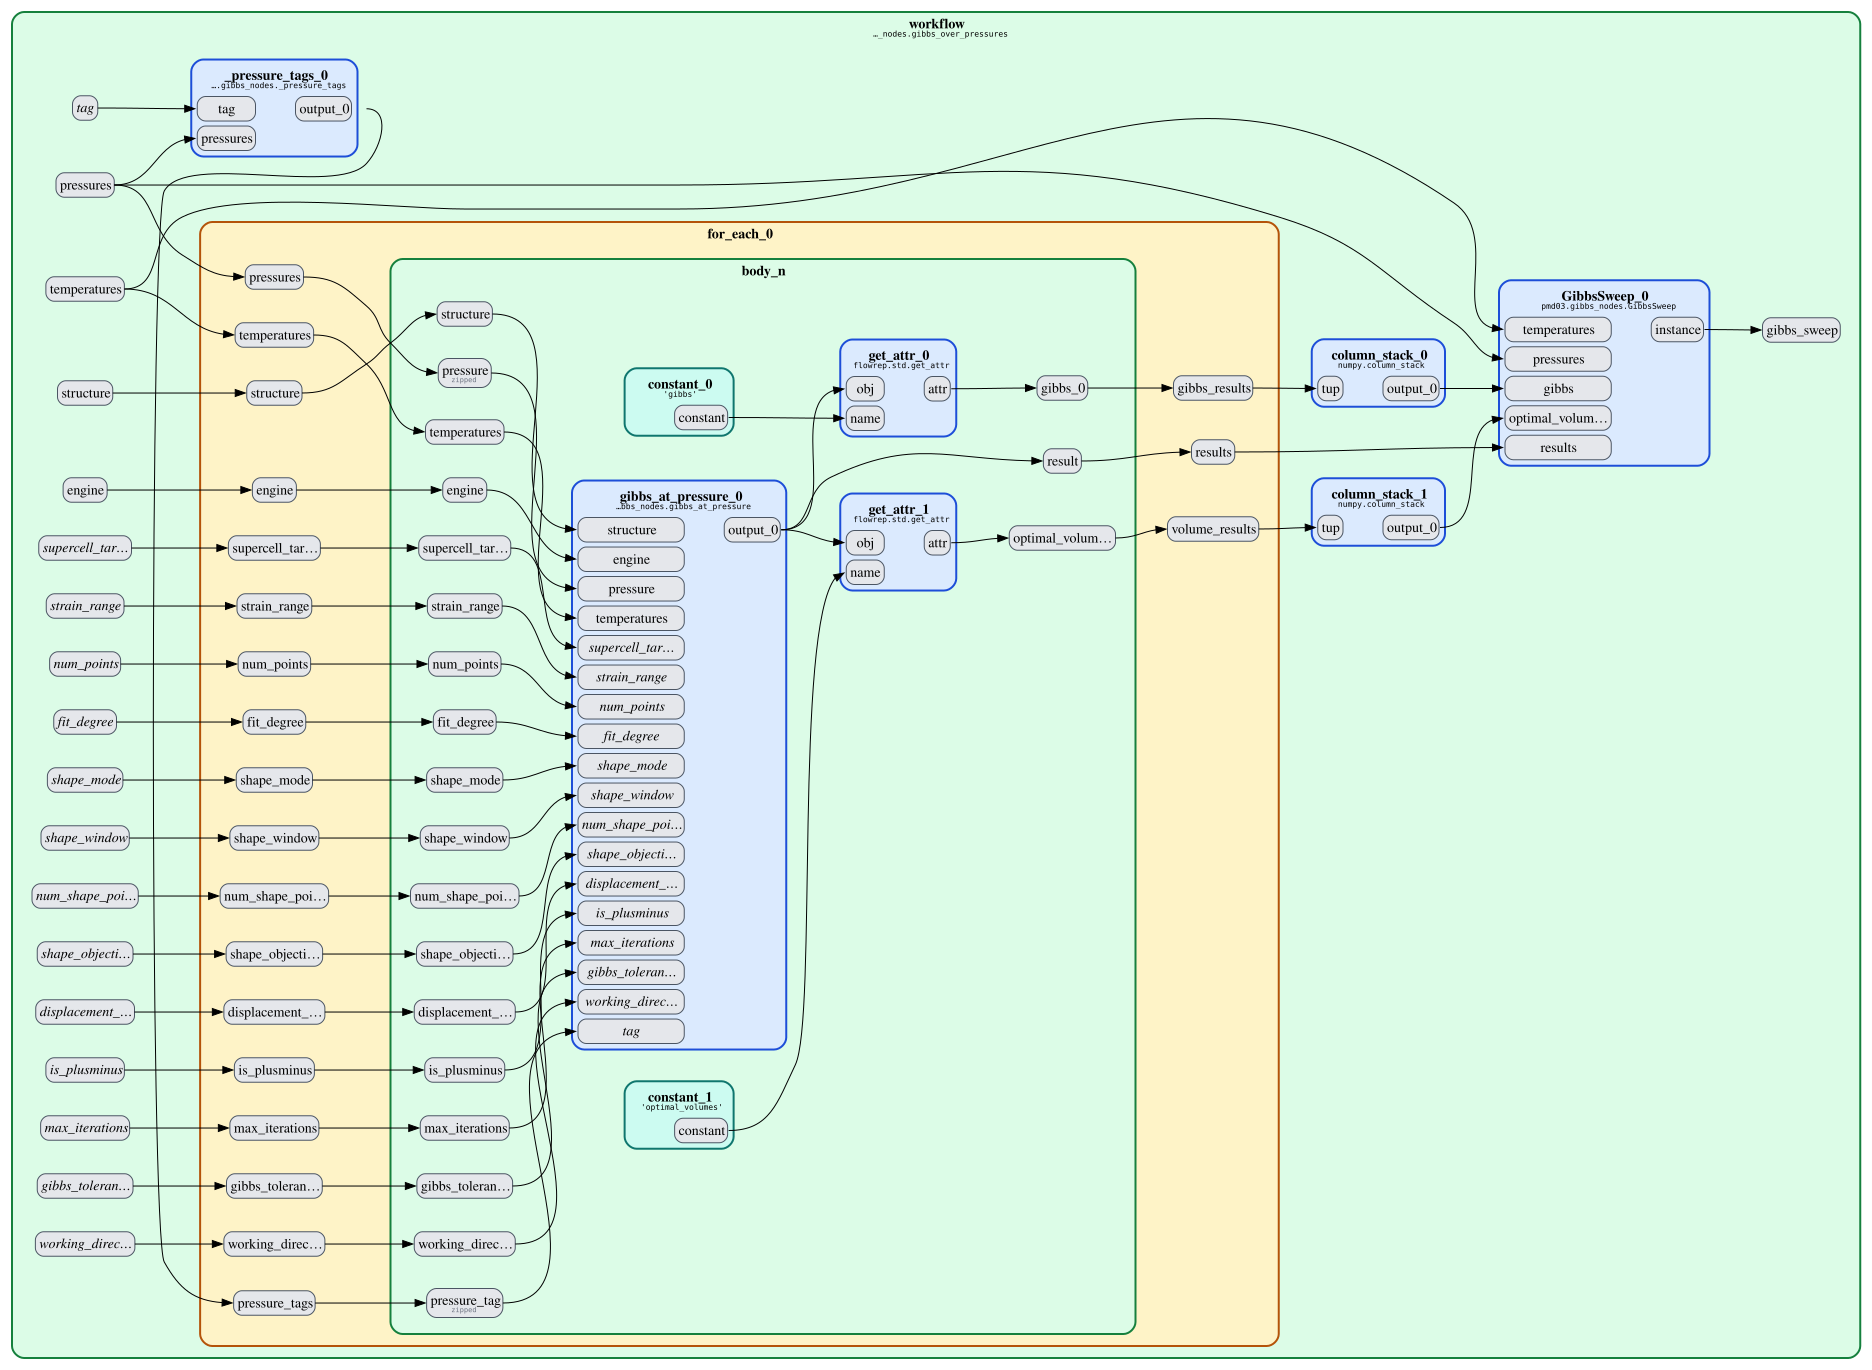

In [5]:
wf.fcc_lo.draw(depth=2)

As with our grain boundary demonstration, we run into the problem that `semantikon` cannot currently parse flow controllers (for-loops, here), so we must forgo generating a knowledge graph

This calculation has some complex convergence and can take a little while to run. To accelerate the process, we provide an already-computed version for you saved in a `bagofholding.H5Bag` hdf5 file. If that's here, we'll just load it.

In [6]:
# Set True for quick (~2 min when fully parallelized), low-fidelity settings -- good for testing not for interesting physics
cheap = False

# If there's a cached result, use it
use_result = True

# If we ran, (over)write the existing cache
write_result = False

# With complete parallelization, "Full" parameters take about 9 minutes to run,
# Under the same conditions, "Cheap" parameters about 3 minutes,
# On GitHub CI and binder these may be significantly longer due to fewer available cores
# Loading the saved result takes ~12 seconds

In [7]:
# pyiron_workflow_atomistics 0.2.2 reports a git-derived `__version__`; use its
# installed package version instead
version_scraping = {"pyiron_workflow_atomistics": importlib.metadata.version}
result_file = pathlib.Path("results/phase_run.h5")

if use_result:
    print("Loading...")
    run = boh.H5Bag(result_file).load(version_scraping=version_scraping, version_validator="semantic-minor")
else:
    WORKING_DIR = "demo_runs"

    engine = engine_mod.ASEEngine(
        EngineInput=engine_mod.CalcInputStatic(),
        calculator=pmd03.SerializableEAM(potential="resources/Pb_II_Wang_2018.eam.alloy", form="alloy"),
        working_directory=WORKING_DIR,
        record_interval=100,
    )

    if cheap:
        temperatures = np.linspace(0.0, 600.0, 3)
        pressures_lo = [52.0, 61.0]
        pressures_hi = [78.0, 90.0]
        gibbs_tolerance = 2e-3
    else:
        temperatures = np.linspace(0.0, 600.0, 12)
        pressures_lo = [52.0, 56.0, 58.0, 60.0, 61.0]
        pressures_hi = [78.0, 81.0, 84.0, 85.0, 86.0, 87.0, 90.0]
        gibbs_tolerance = 2e-4

    num_points = 5
    shape_objective = "static"
    max_iter = 15

    with futures.ProcessPoolExecutor(
            max_workers=2 * (len(pressures_hi) + len(pressures_lo))
    ) as executor:
        wf.fcc_lo.for_each_0.body.executor = executor
        wf.hcp_lo.for_each_0.body.executor = executor
        wf.hcp_hi.for_each_0.body.executor = executor
        wf.bcc_hi.for_each_0.body.executor = executor
        run = wf.run(
            working_directory=WORKING_DIR,
            fcc_structure_lo=fcc_at(HCP_V_57GPA),
            hcp_structure_lo=hcp_at(HCP_V_57GPA),
            hcp_structure_hi=hcp_at(HCP_V_84GPA),
            bcc_structure_hi=bcc_at(HCP_V_84GPA),
            engine=engine,
            pressures_lo=pressures_lo,
            pressures_hi=pressures_hi,
            temperatures=temperatures,
            shape_objective=shape_objective,
            gibbs_tolerance=gibbs_tolerance,
            num_points=num_points,
            max_iterations=max_iter,
            fcc_tag_lo="fcc_sweep_lo",
            hcp_tag_lo="hcp_sweep_lo",
            hcp_tag_hi="hcp_sweep_hi",
            bcc_tag_hi="bcc_sweep_hi",
        )
    if write_result:
        result_file.parent.mkdir(exist_ok=True)
        boh.H5Bag.save(
            run,
            result_file,
            overwrite_existing=True,
            version_scraping=version_scraping,
        )

    shutil.rmtree(WORKING_DIR)

# Read the sweep settings back from the run, so the plots match a loaded cache too
temperatures, pressures_lo, pressures_hi = (
    run.result.input_ports[label].value
    for label in ("temperatures", "pressures_lo", "pressures_hi")
)

Finally, regardless of whether we've re-executed or just loaded our results, let's plot them and look at Gibbs energy crossovers between FCC, HCP, and BCC phases.

First, let's study the energy difference for phase-pairs at different pressures as a function of temperature. Where the lines cross a Gibbs phase energy of 0 indicates a transition temperature from one phase to the other.

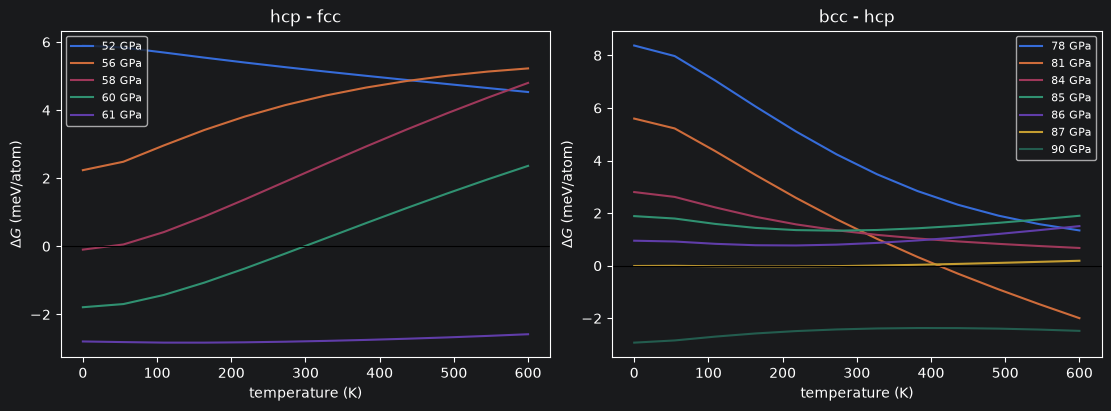

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for index, pressure in enumerate(pressures_lo):
    axes[0].plot(
        temperatures,
        (
            run.outputs.hcp_sweep_lo.gibbs[:, index]
            - run.outputs.fcc_sweep_lo.gibbs[:, index]
        ) * 1000.0,
        label=f"{pressure:.0f} GPa",
    )
axes[0].set_title("hcp - fcc")
for index, pressure in enumerate(pressures_hi):
    axes[1].plot(
        temperatures,
        (
            run.outputs.bcc_sweep_hi.gibbs[:, index]
            - run.outputs.hcp_sweep_hi.gibbs[:, index]
        ) * 1000.0,
        label=f"{pressure:.0f} GPa",
    )
axes[1].set_title("bcc - hcp")
for axis in axes:
    axis.axhline(0.0, color="k", lw=0.8)
    axis.set_xlabel("temperature (K)")
    axis.set_ylabel(r"$\Delta G$ (meV/atom)")
    axis.legend(fontsize=8)
plt.show()

Next, we can run interpolation on our temperature-pressure dataset to extrapolate our individual pressure and temperature results into $(P, T)$ curves delineating our preferred phases -- I.e., we can construct the unary phase diagram

fcc/hcp boundary (GPa): [57.92 58.06 58.45 58.9  59.36 59.8  60.08 60.2  60.29 60.37 60.43 60.48]
hcp/bcc boundary (GPa): [86.99 87.   86.98 86.96 86.96 86.98 87.01 87.04 80.65 80.04 79.56 79.21]


/var/folders/nn/6kd6nhmj2rx7610kd9r_8h0m0000gn/T/ipykernel_29894/128982590.py:5: UserWarning: G_a - G_b changes sign 3 times at temperature index 8 (T = 436.4 K): crossings bracketed at pressures [78.0, 81.0, 87.0] GPa. Taking the first. With a ΔG this small a spurious flip near zero is plausible; check the ΔG curve before trusting the boundary.
  boundary_hi = pmd03.phase_boundary(
/var/folders/nn/6kd6nhmj2rx7610kd9r_8h0m0000gn/T/ipykernel_29894/128982590.py:5: UserWarning: G_a - G_b changes sign 3 times at temperature index 9 (T = 490.9 K): crossings bracketed at pressures [78.0, 81.0, 87.0] GPa. Taking the first. With a ΔG this small a spurious flip near zero is plausible; check the ΔG curve before trusting the boundary.
  boundary_hi = pmd03.phase_boundary(
/var/folders/nn/6kd6nhmj2rx7610kd9r_8h0m0000gn/T/ipykernel_29894/128982590.py:5: UserWarning: G_a - G_b changes sign 3 times at temperature index 10 (T = 545.5 K): crossings bracketed at pressures [78.0, 81.0, 87.0] GPa. Taking 

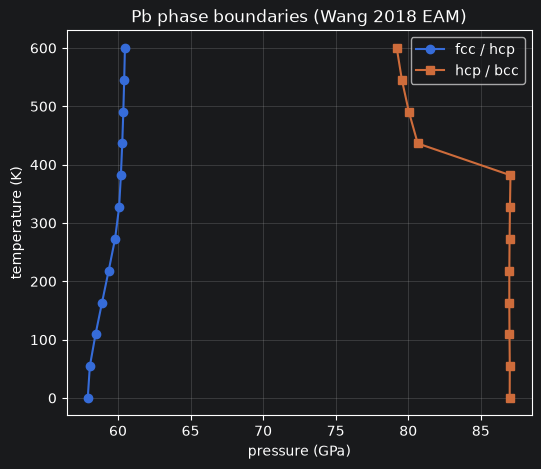

In [9]:
boundary_lo = pmd03.phase_boundary(
    run.outputs.fcc_sweep_lo,
    run.outputs.hcp_sweep_lo,
)
boundary_hi = pmd03.phase_boundary(
    run.outputs.hcp_sweep_hi,
    run.outputs.bcc_sweep_hi,
)
print("fcc/hcp boundary (GPa):", np.round(boundary_lo, 2))
print("hcp/bcc boundary (GPa):", np.round(boundary_hi, 2))
# print("hcp/bcc boundary (GPa):", np.round(boundary_hi, 2))

plt.figure(figsize=(6, 5))
plt.plot(boundary_lo, temperatures, "o-", label="fcc / hcp")
plt.plot(boundary_hi, temperatures, "s-", label="hcp / bcc")
plt.xlabel("pressure (GPa)")
plt.ylabel("temperature (K)")
plt.title("Pb phase boundaries (Wang 2018 EAM)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()